In [ ]:
# ============================================================
# FIXED UCI HAR DATASET DOWNLOAD AND EXTRACTION
# ============================================================

import os
import zipfile
import urllib.request
import shutil

# ------------------------------------------------------------
# 1. Folder paths
# ------------------------------------------------------------

BASE_PATH = "/content/Experiment_6"
DATASET_PATH = os.path.join(BASE_PATH, "dataset")

os.makedirs(DATASET_PATH, exist_ok=True)

ZIP_FILE = os.path.join(
    DATASET_PATH,
    "uci_har_dataset.zip"
)

EXTRACT_PATH = os.path.join(
    DATASET_PATH,
    "extracted"
)

# ------------------------------------------------------------
# 2. Download the outer ZIP
# ------------------------------------------------------------

ZIP_URL = (
    "https://archive.ics.uci.edu/static/public/240/"
    "human+activity+recognition+using+smartphones.zip"
)

print("Downloading dataset...")

urllib.request.urlretrieve(
    ZIP_URL,
    ZIP_FILE
)

print("Outer ZIP downloaded")


# ------------------------------------------------------------
# 3. Remove old extraction folder
# ------------------------------------------------------------

if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

os.makedirs(EXTRACT_PATH, exist_ok=True)


# ------------------------------------------------------------
# 4. Extract outer ZIP
# ------------------------------------------------------------

print("Extracting outer ZIP...")

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Outer ZIP extracted")


# ------------------------------------------------------------
# 5. Find and extract inner ZIP
# ------------------------------------------------------------

inner_zip_path = None

for root, folders, files in os.walk(EXTRACT_PATH):

    for file in files:

        if file.lower().endswith(".zip"):

            inner_zip_path = os.path.join(
                root,
                file
            )

            break

    if inner_zip_path is not None:
        break


if inner_zip_path is None:

    raise FileNotFoundError(
        "Inner ZIP file was not found."
    )


print("Inner ZIP found:")
print(inner_zip_path)


INNER_EXTRACT_PATH = os.path.join(
    EXTRACT_PATH,
    "final_dataset"
)

os.makedirs(
    INNER_EXTRACT_PATH,
    exist_ok=True
)


print("Extracting inner ZIP...")

with zipfile.ZipFile(
    inner_zip_path,
    "r"
) as zip_ref:

    zip_ref.extractall(
        INNER_EXTRACT_PATH
    )

print("Inner ZIP extracted")


# ------------------------------------------------------------
# 6. Find actual UCI HAR Dataset folder
# ------------------------------------------------------------

data_path = None

for root, folders, files in os.walk(
    INNER_EXTRACT_PATH
):

    if (
        "activity_labels.txt" in files
        and "train" in folders
        and "test" in folders
    ):

        data_path = root
        break


if data_path is None:

    print("\nAll extracted folders:\n")

    for root, folders, files in os.walk(
        INNER_EXTRACT_PATH
    ):

        print("\nFolder:", root)

        for file in files[:10]:
            print("   ", file)

    raise FileNotFoundError(
        "Actual UCI HAR Dataset folder was not found."
    )


print("\n================================================")
print("DATASET FOUND SUCCESSFULLY")
print("================================================")

print(data_path)


# ============================================================
# EXPERIMENT 6 - STEP 5: PREPROCESSING
# UCI HAR DATASET
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------
# 1. Check dataset path
# ------------------------------------------------------------

print("Dataset path:")
print(data_path)

# ------------------------------------------------------------
# 2. Define raw signal folders
# ------------------------------------------------------------

TRAIN_SIGNAL_PATH = os.path.join(
    data_path,
    "train",
    "Inertial Signals"
)

TEST_SIGNAL_PATH = os.path.join(
    data_path,
    "test",
    "Inertial Signals"
)

TRAIN_LABEL_FILE = os.path.join(
    data_path,
    "train",
    "y_train.txt"
)

TEST_LABEL_FILE = os.path.join(
    data_path,
    "test",
    "y_test.txt"
)

ACTIVITY_LABEL_FILE = os.path.join(
    data_path,
    "activity_labels.txt"
)

# ------------------------------------------------------------
# 3. Check paths
# ------------------------------------------------------------

print("\nChecking files...")

print("Train signals:", os.path.exists(TRAIN_SIGNAL_PATH))
print("Test signals:", os.path.exists(TEST_SIGNAL_PATH))
print("Train labels:", os.path.exists(TRAIN_LABEL_FILE))
print("Test labels:", os.path.exists(TEST_LABEL_FILE))

# ------------------------------------------------------------
# 4. Load raw inertial signals
# ------------------------------------------------------------

# Three body acceleration signals
body_acc_x_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "body_acc_x_train.txt"
    )
)

body_acc_y_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "body_acc_y_train.txt"
    )
)

body_acc_z_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "body_acc_z_train.txt"
    )
)

# Three body gyroscope signals
body_gyro_x_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "body_gyro_x_train.txt"
    )
)

body_gyro_y_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "body_gyro_y_train.txt"
    )
)

body_gyro_z_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "body_gyro_z_train.txt"
    )
)

# Three total acceleration signals
total_acc_x_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "total_acc_x_train.txt"
    )
)

total_acc_y_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "total_acc_y_train.txt"
    )
)

total_acc_z_train = np.loadtxt(
    os.path.join(
        TRAIN_SIGNAL_PATH,
        "total_acc_z_train.txt"
    )
)

# ------------------------------------------------------------
# 5. Arrange training data as (N, 128, 9)
# ------------------------------------------------------------

X_train_full = np.stack(
    [
        body_acc_x_train,
        body_acc_y_train,
        body_acc_z_train,
        body_gyro_x_train,
        body_gyro_y_train,
        body_gyro_z_train,
        total_acc_x_train,
        total_acc_y_train,
        total_acc_z_train
    ],
    axis=2
)

print("\nTraining data shape:")
print(X_train_full.shape)

# ------------------------------------------------------------
# 6. Load test signals
# ------------------------------------------------------------

body_acc_x_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "body_acc_x_test.txt"
    )
)

body_acc_y_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "body_acc_y_test.txt"
    )
)

body_acc_z_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "body_acc_z_test.txt"
    )
)

body_gyro_x_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "body_gyro_x_test.txt"
    )
)

body_gyro_y_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "body_gyro_y_test.txt"
    )
)

body_gyro_z_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "body_gyro_z_test.txt"
    )
)

total_acc_x_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "total_acc_x_test.txt"
    )
)

total_acc_y_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "total_acc_y_test.txt"
    )
)

total_acc_z_test = np.loadtxt(
    os.path.join(
        TEST_SIGNAL_PATH,
        "total_acc_z_test.txt"
    )
)

# ------------------------------------------------------------
# 7. Arrange test data as (N, 128, 9)
# ------------------------------------------------------------

X_test = np.stack(
    [
        body_acc_x_test,
        body_acc_y_test,
        body_acc_z_test,
        body_gyro_x_test,
        body_gyro_y_test,
        body_gyro_z_test,
        total_acc_x_test,
        total_acc_y_test,
        total_acc_z_test
    ],
    axis=2
)

print("Testing data shape:")
print(X_test.shape)

# ------------------------------------------------------------
# 8. Load activity labels
# ------------------------------------------------------------

y_train_full = np.loadtxt(
    TRAIN_LABEL_FILE,
    dtype=int
)

y_test = np.loadtxt(
    TEST_LABEL_FILE,
    dtype=int
)

# Activity names
activity_names = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

print("\nActivity labels:")
for number, name in activity_names.items():
    print(number, ":", name)

# ------------------------------------------------------------
# 9. Select a manageable subset
# ------------------------------------------------------------

# Recommended subset: 3000 training windows
# Change this to 1500 if Colab RAM is low.

SUBSET_SIZE = 3000

if SUBSET_SIZE > len(X_train_full):
    SUBSET_SIZE = len(X_train_full)

# Stratified selection preserves all six classes
X_subset, _, y_subset, _ = train_test_split(
    X_train_full,
    y_train_full,
    train_size=SUBSET_SIZE,
    random_state=42,
    stratify=y_train_full
)

print("\nSelected subset shape:")
print(X_subset.shape)

# ------------------------------------------------------------
# 10. Create train and validation sets
# ------------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=0.15,
    random_state=42,
    stratify=y_subset
)

print("\nBefore normalization:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

# ------------------------------------------------------------
# 11. Normalize using training data only
# ------------------------------------------------------------

# StandardScaler expects 2D input.
# Reshape temporarily, then convert back to 3D.

N_train = X_train.shape[0]
N_val = X_val.shape[0]
N_test = X_test.shape[0]

# Reshape training data
X_train_2d = X_train.reshape(
    -1,
    X_train.shape[2]
)

X_val_2d = X_val.reshape(
    -1,
    X_val.shape[2]
)

X_test_2d = X_test.reshape(
    -1,
    X_test.shape[2]
)

# Fit only on training data
scaler = StandardScaler()

X_train_2d = scaler.fit_transform(
    X_train_2d
)

X_val_2d = scaler.transform(
    X_val_2d
)

X_test_2d = scaler.transform(
    X_test_2d
)

# Convert back to sequence format
X_train = X_train_2d.reshape(
    N_train,
    128,
    9
)

X_val = X_val_2d.reshape(
    N_val,
    128,
    9
)

X_test = X_test_2d.reshape(
    N_test,
    128,
    9
)

# ------------------------------------------------------------
# 12. Encode labels from 1-6 to 0-5
# ------------------------------------------------------------

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    y_train
)

y_val = label_encoder.transform(
    y_val
)

y_test = label_encoder.transform(
    y_test
)

# ------------------------------------------------------------
# 13. Verify final shapes
# ------------------------------------------------------------

print("\n================================================")
print("STEP 5 - PREPROCESSING COMPLETED")
print("================================================")

print("Training shape   :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Testing shape    :", X_test.shape)

print("Number of classes:", len(label_encoder.classes_))
print("Features per time step:", X_train.shape[2])
print("Sequence length:", X_train.shape[1])

# ------------------------------------------------------------
# 14. Verify class distribution
# ------------------------------------------------------------

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nActivity class names:")
for i, name in enumerate(label_encoder.classes_):
    print(i, ":", activity_names[name])

# ------------------------------------------------------------
# 15. Check normalization
# ------------------------------------------------------------

print("\nMean of training data:")
print(np.mean(X_train, axis=(0, 1)))

print("\nStandard deviation of training data:")
print(np.std(X_train, axis=(0, 1)))

print("\nPreprocessing finished successfully!")

Outer ZIP downloaded
Extracting outer ZIP...
Outer ZIP extracted
Inner ZIP found:
/content/Experiment_6/dataset/extracted/UCI HAR Dataset.zip
Extracting inner ZIP...
Inner ZIP extracted

DATASET FOUND SUCCESSFULLY
/content/Experiment_6/dataset/extracted/final_dataset/UCI HAR Dataset
Dataset path:
/content/Experiment_6/dataset/extracted/final_dataset/UCI HAR Dataset

Checking files...
Train signals: True
Test signals: True
Train labels: True
Test labels: True

Training data shape:
(7352, 128, 9)
Testing data shape:
(2947, 128, 9)

Activity labels:
1 : WALKING
2 : WALKING_UPSTAIRS
3 : WALKING_DOWNSTAIRS
4 : SITTING
5 : STANDING
6 : LAYING

Selected subset shape:
(3000, 128, 9)

Before normalization:
Training: (2550, 128, 9)
Validation: (450, 128, 9)
Testing: (2947, 128, 9)

STEP 5 - PREPROCESSING COMPLETED
Training shape   : (2550, 128, 9)
Validation shape : (450, 128, 9)
Testing shape    : (2947, 128, 9)
Number of classes: 6
Features per time step: 9
Sequence length: 128

Training class

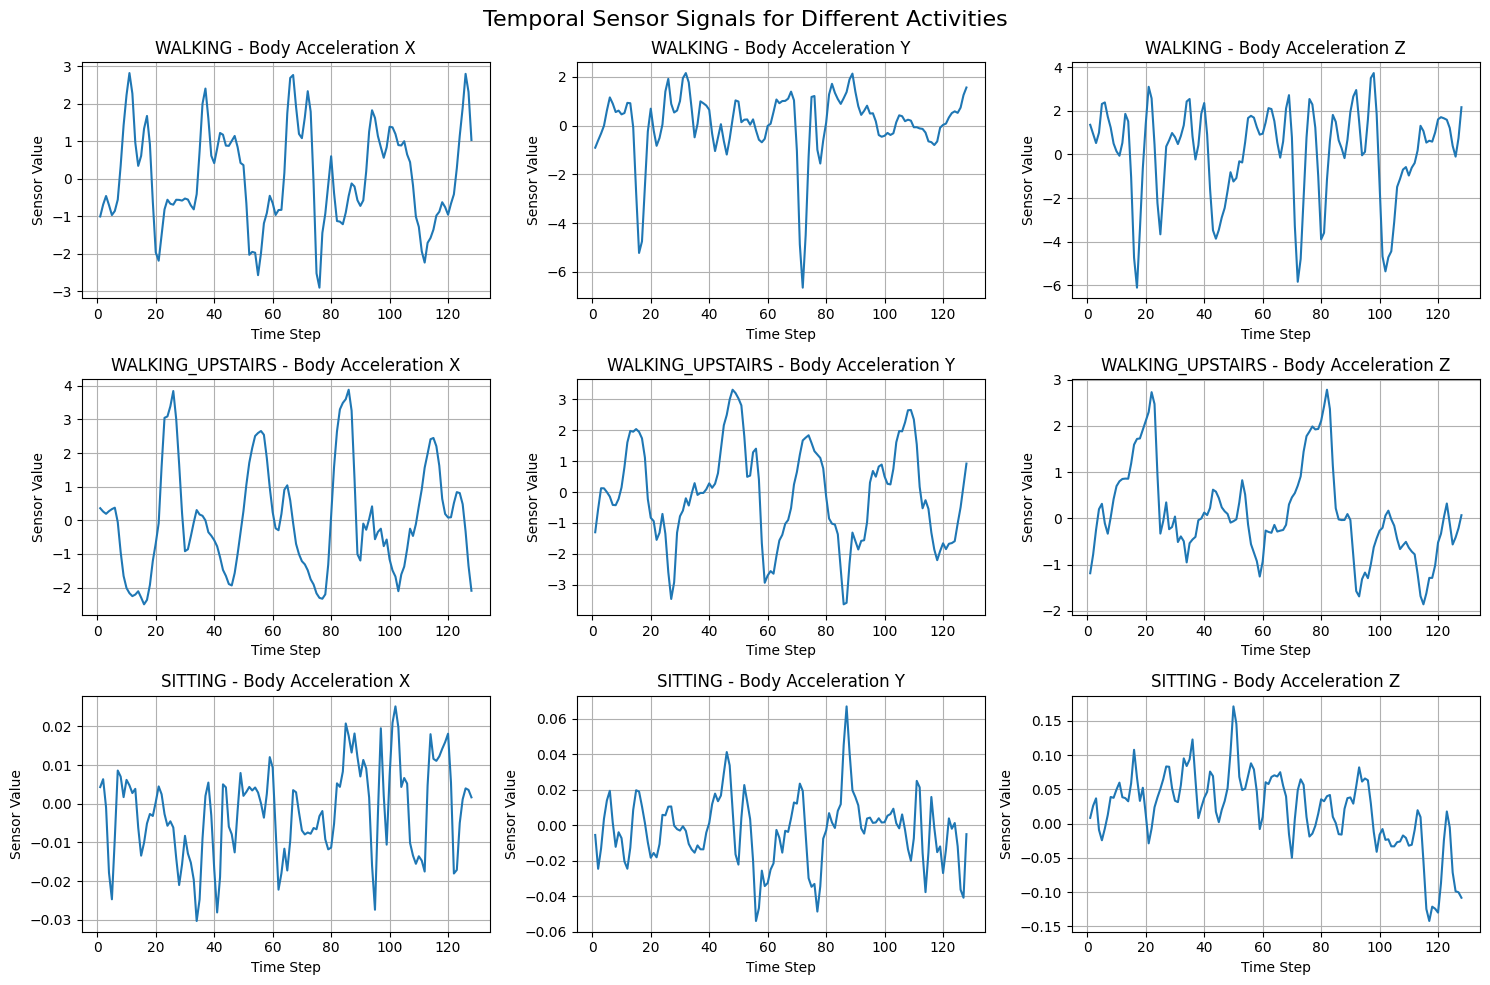

Temporal visualization completed.

Selected activities:
0 : WALKING
1 : WALKING_UPSTAIRS
3 : SITTING

Each sequence contains:
Time steps: 128
Sensor channels: 9


In [ ]:

# ============================================================
# EXPERIMENT 6 - STEP 6: TEMPORAL DATA VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Select three activity classes
# ------------------------------------------------------------

selected_classes = [0, 1, 3]

# 0 = WALKING
# 1 = WALKING_UPSTAIRS
# 3 = SITTING

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# ------------------------------------------------------------
# 2. Select three sensor channels
# ------------------------------------------------------------

selected_channels = [0, 1, 2]

channel_names = [
    "Body Acceleration X",
    "Body Acceleration Y",
    "Body Acceleration Z"
]

# Time steps
time_steps = np.arange(1, 129)

# ------------------------------------------------------------
# 3. Plot representative sequences
# ------------------------------------------------------------

plt.figure(figsize=(15, 10))

plot_number = 1

for class_id in selected_classes:

    # Find samples belonging to this class
    indices = np.where(y_train == class_id)[0]

    # Select the first sample
    sample_index = indices[0]

    sample = X_train[sample_index]

    for channel_id in selected_channels:

        plt.subplot(
            3,
            3,
            plot_number
        )

        plt.plot(
            time_steps,
            sample[:, channel_id]
        )

        plt.title(
            class_names[class_id]
            + " - "
            + channel_names[channel_id]
        )

        plt.xlabel("Time Step")
        plt.ylabel("Sensor Value")

        plt.grid(True)

        plot_number += 1

plt.suptitle(
    "Temporal Sensor Signals for Different Activities",
    fontsize=16
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 4. Print selected samples
# ------------------------------------------------------------

print("Temporal visualization completed.")

print("\nSelected activities:")
for class_id in selected_classes:
    print(class_id, ":", class_names[class_id])

print("\nEach sequence contains:")
print("Time steps:", X_train.shape[1])
print("Sensor channels:", X_train.shape[2])

In [ ]:
X_train
X_val
X_test

y_train
y_val
y_test

array([4, 4, 4, ..., 1, 1, 1])

Input data shapes:
X_train: (2550, 128, 9)
X_val  : (450, 128, 9)
X_test : (2947, 128, 9)
y_train: (2550,)
y_val  : (450,)
y_test : (2947,)

VANILLA RNN MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)


Training Vanilla RNN...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.4439 - loss: 1.5294 - val_accuracy: 0.5422 - val_loss: 1.2509
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5965 - loss: 1.0628 - val_accuracy: 0.6489 - val_loss: 0.9054
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6647 - loss: 0.8131 - val_accuracy: 0.6556 - val_loss: 0.8122
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5812 - loss: 0.9984 - val_accuracy: 0.5178 - val_loss: 1.2002
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5482 - loss: 1.0463 - val_accuracy: 0.6800 - val_loss: 0.9387
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6408 - loss: 0.8846 - val_accuracy: 0.6600 - val_loss: 0.8436
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6627 - loss: 0.7928 - val_accuracy: 0.7022 - val_loss: 0.7102
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6871 - loss: 0.7023 -

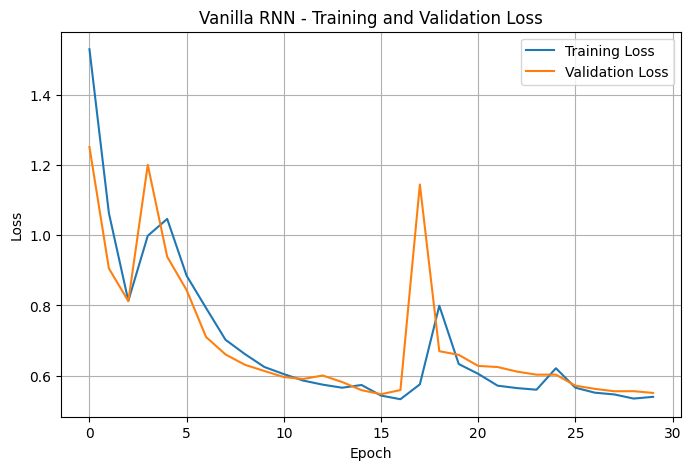

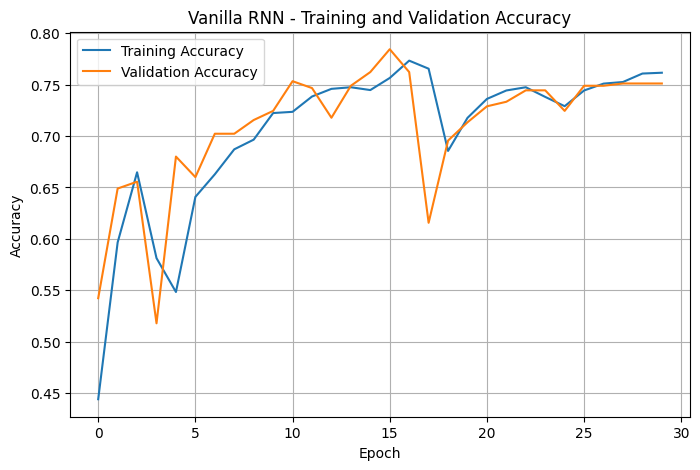


TESTING VANILLA RNN
Test Loss: 0.6712
Test Accuracy: 71.39 %

VANILLA RNN PERFORMANCE
Accuracy: 71.39 %
Macro Precision: 71.13 %
Macro Recall: 70.28 %
Macro F1-score: 70.54 %

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.50      0.59      0.54       496
  WALKING_UPSTAIRS       0.59      0.56      0.58       471
WALKING_DOWNSTAIRS       0.57      0.52      0.54       420
           SITTING       0.83      0.75      0.79       491
          STANDING       0.78      0.85      0.81       532
            LAYING       0.99      0.95      0.97       537

          accuracy                           0.71      2947
         macro avg       0.71      0.70      0.71      2947
      weighted avg       0.72      0.71      0.72      2947



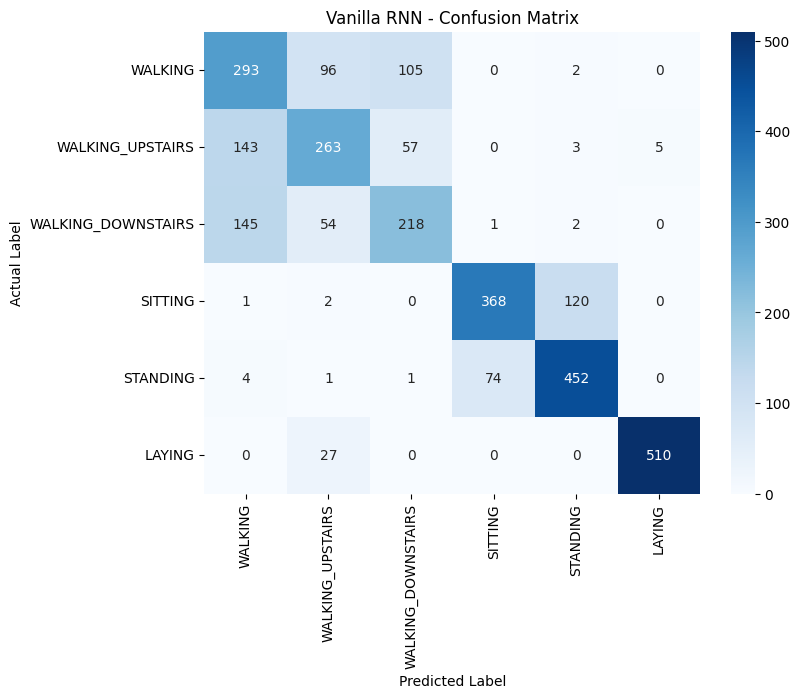


Trainable parameters: 1974
Training time: 33.93 seconds

RNN results saved.
{'Model': 'Vanilla RNN', 'Accuracy': 71.39463861554123, 'Macro Precision': 71.12508793840368, 'Macro Recall': 70.2832567160136, 'Macro F1': 70.54455455252179, 'Parameters': 1974, 'Training Time': 33.9321768283844}


In [ ]:

# ============================================================
# EXPERIMENT 6 - STEP 7, 8, 9
# VANILLA RNN FOR HUMAN ACTIVITY RECOGNITION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense

from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

import time

# ------------------------------------------------------------
# 1. Check input data
# ------------------------------------------------------------

print("Input data shapes:")

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

# ------------------------------------------------------------
# 2. Build Vanilla RNN model
# ------------------------------------------------------------

rnn_model = Sequential(

    [

        Input(
            shape=(128, 9)
        ),

        SimpleRNN(
            32,
            activation="tanh"
        ),

        Dropout(
            0.2
        ),

        Dense(
            16,
            activation="relu"
        ),

        Dense(
            6,
            activation="softmax"
        )

    ]

)

# ------------------------------------------------------------
# 3. Compile model
# ------------------------------------------------------------

rnn_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# ------------------------------------------------------------
# 4. Display model summary
# ------------------------------------------------------------

print("\n================================================")
print("VANILLA RNN MODEL SUMMARY")
print("================================================")

rnn_model.summary()

# ------------------------------------------------------------
# 5. Train the model
# ------------------------------------------------------------

print("\nTraining Vanilla RNN...")

start_time = time.time()

rnn_history = rnn_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=32,

    verbose=1

)

end_time = time.time()

rnn_training_time = end_time - start_time

print("\nTraining completed.")

print(
    "Training time:",
    round(rnn_training_time, 2),
    "seconds"
)

# ------------------------------------------------------------
# 6. Plot training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Vanilla RNN - Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 7. Plot training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Vanilla RNN - Training and Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 8. Evaluate on test data
# ------------------------------------------------------------

print("\n================================================")
print("TESTING VANILLA RNN")
print("================================================")

test_loss, test_accuracy = rnn_model.evaluate(

    X_test,
    y_test,

    verbose=0

)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 9. Predict test labels
# ------------------------------------------------------------

y_probability = rnn_model.predict(

    X_test,

    verbose=0

)

y_pred = np.argmax(
    y_probability,
    axis=1
)

# ------------------------------------------------------------
# 10. Calculate performance metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("\n================================================")
print("VANILLA RNN PERFORMANCE")
print("================================================")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Macro Precision:",
    round(precision * 100, 2),
    "%"
)

print(
    "Macro Recall:",
    round(recall * 100, 2),
    "%"
)

print(
    "Macro F1-score:",
    round(f1 * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 11. Classification report
# ------------------------------------------------------------

activity_names_list = [

    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"

]

print("\nClassification Report:")

print(

    classification_report(

        y_test,
        y_pred,

        labels=[0, 1, 2, 3, 4, 5],

        target_names=activity_names_list,

        zero_division=0

    )

)

# ------------------------------------------------------------
# 12. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(

    y_test,
    y_pred,

    labels=[0, 1, 2, 3, 4, 5]

)

plt.figure(figsize=(8, 6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=activity_names_list,

    yticklabels=activity_names_list

)

plt.title(
    "Vanilla RNN - Confusion Matrix"
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

# ------------------------------------------------------------
# 13. Trainable parameters
# ------------------------------------------------------------

trainable_parameters = rnn_model.count_params()

print(
    "\nTrainable parameters:",
    trainable_parameters
)

print(
    "Training time:",
    round(rnn_training_time, 2),
    "seconds"
)

# ------------------------------------------------------------
# 14. Store RNN results
# ------------------------------------------------------------

rnn_results = {

    "Model": "Vanilla RNN",

    "Accuracy": accuracy * 100,

    "Macro Precision": precision * 100,

    "Macro Recall": recall * 100,

    "Macro F1": f1 * 100,

    "Parameters": trainable_parameters,

    "Training Time": rnn_training_time

}

print("\nRNN results saved.")

print(rnn_results)

LSTM MODEL SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.3694 - loss: 1.5379 - val_accuracy: 0.6067 - val_loss: 1.2395
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6702 - loss: 1.0476 - val_accuracy: 0.7378 - val_loss: 0.8527
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7718 - loss: 0.6867 - val_accuracy: 0.8044 - val_loss: 0.5382
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8494 - loss: 0.4589 - val_accuracy: 0.8467 - val_loss: 0.4313
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9016 - loss: 0.3195 - val_accuracy: 0.9222 - val_loss: 0.2615
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8961 - loss: 0.3181 - val_accuracy: 0.9000 - val_loss: 0.2743
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9247 - loss: 0.2276 - val_accuracy: 0.9222 - val_loss: 0.2221
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9404 - loss: 0.1716 - val_ac

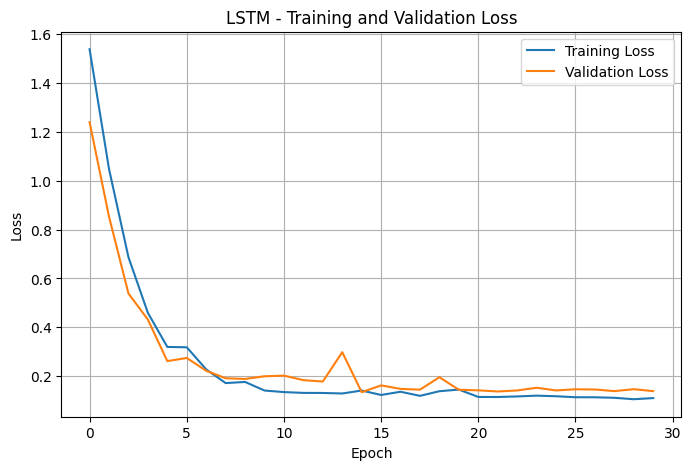

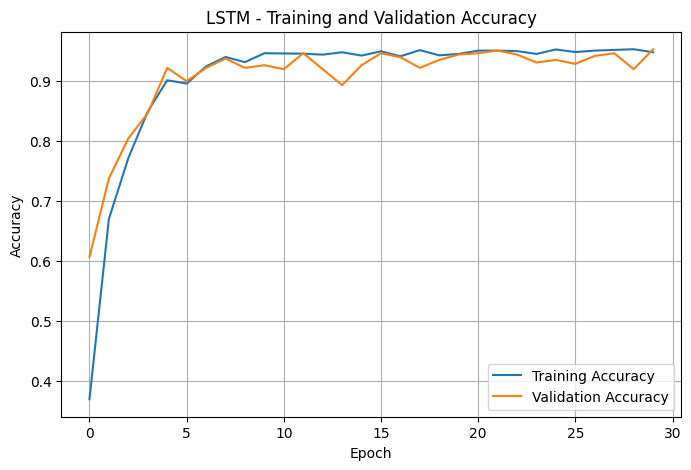


LSTM TESTING
Test Loss: 0.4172
Test Accuracy: 89.58 %

LSTM PERFORMANCE
Accuracy: 89.58 %
Macro Precision: 89.54 %
Macro Recall: 89.79 %
Macro F1-score: 89.62 %

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.96      0.95      0.96       496
  WALKING_UPSTAIRS       0.88      0.94      0.91       471
WALKING_DOWNSTAIRS       0.90      0.96      0.93       420
           SITTING       0.79      0.79      0.79       491
          STANDING       0.85      0.80      0.83       532
            LAYING       0.99      0.95      0.97       537

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



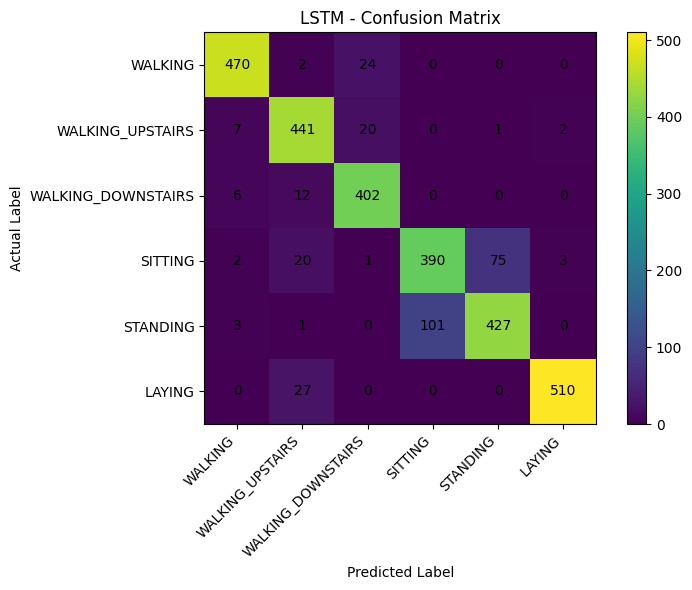


Trainable parameters: 6006
Training time: 35.38 seconds

LSTM results saved.
{'Model': 'LSTM', 'Accuracy': 89.58262639972854, 'Macro Precision': 89.54463918162135, 'Macro Recall': 89.79464727448023, 'Macro F1': 89.61940358610545, 'Parameters': 6006, 'Training Time': 35.38163495063782}


In [ ]:

# ============================================================
# LSTM MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Build LSTM model
# ------------------------------------------------------------

lstm_model = Sequential([

    Input(shape=(128, 9)),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(6, activation="softmax")

])

# ------------------------------------------------------------
# 2. Compile model
# ------------------------------------------------------------

lstm_model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# ------------------------------------------------------------
# 3. Model summary
# ------------------------------------------------------------

print("================================================")
print("LSTM MODEL SUMMARY")
print("================================================")

lstm_model.summary()

# ------------------------------------------------------------
# 4. Train LSTM
# ------------------------------------------------------------

print("\nTraining LSTM...")

start_time = time.time()

lstm_history = lstm_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=30,

    batch_size=32,

    verbose=1

)

end_time = time.time()

lstm_training_time = end_time - start_time

print("\nLSTM training completed.")

print(
    "Training time:",
    round(lstm_training_time, 2),
    "seconds"
)

# ------------------------------------------------------------
# 5. Plot loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM - Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 6. Plot accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM - Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 7. Evaluate on test data
# ------------------------------------------------------------

print("\n================================================")
print("LSTM TESTING")
print("================================================")

test_loss, test_accuracy = lstm_model.evaluate(

    X_test,
    y_test,

    verbose=0

)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 8. Predict test labels
# ------------------------------------------------------------

y_probability_lstm = lstm_model.predict(

    X_test,

    verbose=0

)

y_pred_lstm = np.argmax(

    y_probability_lstm,

    axis=1

)

# ------------------------------------------------------------
# 9. Calculate metrics
# ------------------------------------------------------------

lstm_accuracy = accuracy_score(
    y_test,
    y_pred_lstm
)

lstm_precision = precision_score(
    y_test,
    y_pred_lstm,
    average="macro",
    zero_division=0
)

lstm_recall = recall_score(
    y_test,
    y_pred_lstm,
    average="macro",
    zero_division=0
)

lstm_f1 = f1_score(
    y_test,
    y_pred_lstm,
    average="macro",
    zero_division=0
)

print("\n================================================")
print("LSTM PERFORMANCE")
print("================================================")

print(
    "Accuracy:",
    round(lstm_accuracy * 100, 2),
    "%"
)

print(
    "Macro Precision:",
    round(lstm_precision * 100, 2),
    "%"
)

print(
    "Macro Recall:",
    round(lstm_recall * 100, 2),
    "%"
)

print(
    "Macro F1-score:",
    round(lstm_f1 * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 10. Classification report
# ------------------------------------------------------------

activity_names_list = [

    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"

]

print("\nClassification Report:")

print(

    classification_report(

        y_test,
        y_pred_lstm,

        labels=[0, 1, 2, 3, 4, 5],

        target_names=activity_names_list,

        zero_division=0

    )

)

# ------------------------------------------------------------
# 11. Confusion matrix
# ------------------------------------------------------------

cm_lstm = confusion_matrix(

    y_test,
    y_pred_lstm,

    labels=[0, 1, 2, 3, 4, 5]

)

plt.figure(figsize=(8, 6))

plt.imshow(
    cm_lstm,
    interpolation="nearest"
)

plt.title("LSTM - Confusion Matrix")

plt.colorbar()

plt.xticks(
    range(6),
    activity_names_list,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(6),
    activity_names_list
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(6):
    for j in range(6):

        plt.text(
            j,
            i,
            cm_lstm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 12. Parameters and results
# ------------------------------------------------------------

lstm_parameters = lstm_model.count_params()

print("\nTrainable parameters:", lstm_parameters)

print(
    "Training time:",
    round(lstm_training_time, 2),
    "seconds"
)

lstm_results = {

    "Model": "LSTM",

    "Accuracy": lstm_accuracy * 100,

    "Macro Precision": lstm_precision * 100,

    "Macro Recall": lstm_recall * 100,

    "Macro F1": lstm_f1 * 100,

    "Parameters": lstm_parameters,

    "Training Time": lstm_training_time

}

print("\nLSTM results saved.")

print(lstm_results)

GRU MODEL SUMMARY


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4000 - loss: 1.4184 - val_accuracy: 0.5244 - val_loss: 1.2562
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5808 - loss: 1.1153 - val_accuracy: 0.6133 - val_loss: 0.9737
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6576 - loss: 0.8566 - val_accuracy: 0.6956 - val_loss: 0.7432
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7569 - loss: 0.6439 - val_accuracy: 0.8089 - val_loss: 0.5504
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8424 - loss: 0.4770 - val_accuracy: 0.8511 - val_loss: 0.3977
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9008 - loss: 0.3189 - val_accuracy: 0.9267 - val_loss: 0.2524
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9184 - loss: 0.2370 - val_accuracy: 0.9467 - val_loss: 0.2002
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9396 - loss: 0.1813 - val_acc

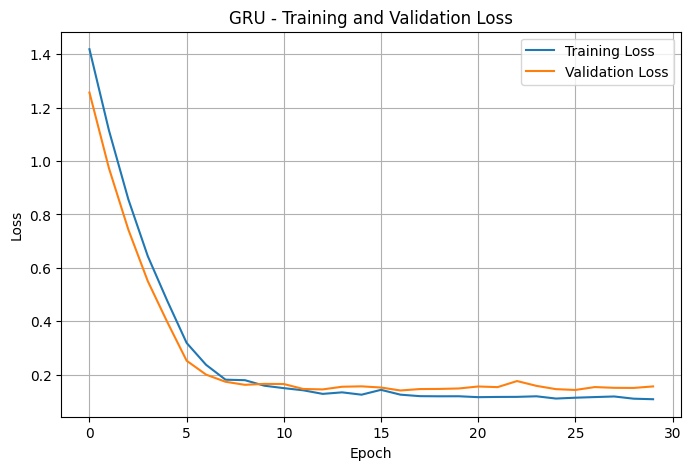

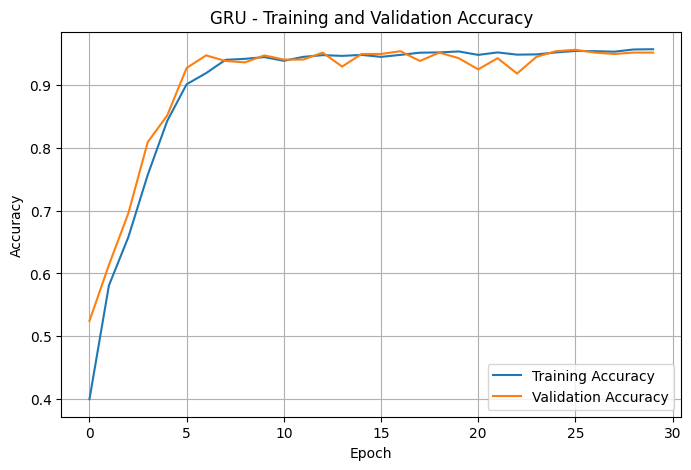


GRU TESTING
Test Loss: 0.4471
Test Accuracy: 89.72 %

GRU PERFORMANCE
Accuracy: 89.72 %
Macro Precision: 89.79 %
Macro Recall: 89.84 %
Macro F1-score: 89.74 %

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.91      1.00      0.95       496
  WALKING_UPSTAIRS       0.89      0.93      0.91       471
WALKING_DOWNSTAIRS       0.95      0.92      0.93       420
           SITTING       0.79      0.80      0.80       491
          STANDING       0.85      0.80      0.82       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



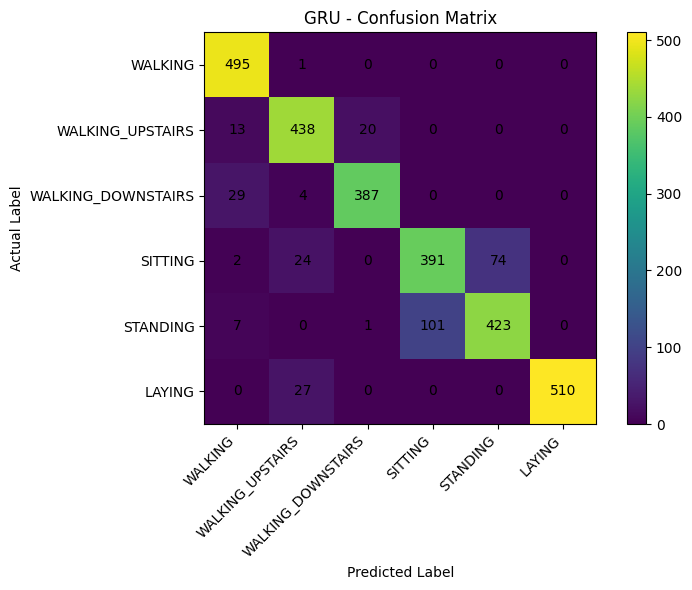


Trainable parameters: 4758
Training time: 30.65 seconds

GRU results saved.
{'Model': 'GRU', 'Accuracy': 89.71835765184933, 'Macro Precision': 89.79307635774964, 'Macro Recall': 89.84193687824508, 'Macro F1': 89.74239956510178, 'Parameters': 4758, 'Training Time': 30.64763331413269}


In [ ]:

# ============================================================
# EXPERIMENT 6 - STEP 11
# GRU FOR HUMAN ACTIVITY RECOGNITION
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Build GRU model
# ------------------------------------------------------------

gru_model = Sequential([

    Input(shape=(128, 9)),

    GRU(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(6, activation="softmax")

])

# ------------------------------------------------------------
# 2. Compile model
# ------------------------------------------------------------

gru_model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# ------------------------------------------------------------
# 3. Model summary
# ------------------------------------------------------------

print("================================================")
print("GRU MODEL SUMMARY")
print("================================================")

gru_model.summary()

# ------------------------------------------------------------
# 4. Train GRU
# ------------------------------------------------------------

print("\nTraining GRU...")

start_time = time.time()

gru_history = gru_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=30,

    batch_size=32,

    verbose=1

)

end_time = time.time()

gru_training_time = end_time - start_time

print("\nGRU training completed.")

print(
    "Training time:",
    round(gru_training_time, 2),
    "seconds"
)

# ------------------------------------------------------------
# 5. Plot training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    gru_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    gru_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("GRU - Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 6. Plot training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    gru_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    gru_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("GRU - Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 7. Evaluate on test data
# ------------------------------------------------------------

print("\n================================================")
print("GRU TESTING")
print("================================================")

test_loss, test_accuracy = gru_model.evaluate(

    X_test,
    y_test,

    verbose=0

)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 8. Predict test labels
# ------------------------------------------------------------

y_probability_gru = gru_model.predict(

    X_test,

    verbose=0

)

y_pred_gru = np.argmax(

    y_probability_gru,

    axis=1

)

# ------------------------------------------------------------
# 9. Calculate metrics
# ------------------------------------------------------------

gru_accuracy = accuracy_score(
    y_test,
    y_pred_gru
)

gru_precision = precision_score(
    y_test,
    y_pred_gru,
    average="macro",
    zero_division=0
)

gru_recall = recall_score(
    y_test,
    y_pred_gru,
    average="macro",
    zero_division=0
)

gru_f1 = f1_score(
    y_test,
    y_pred_gru,
    average="macro",
    zero_division=0
)

print("\n================================================")
print("GRU PERFORMANCE")
print("================================================")

print(
    "Accuracy:",
    round(gru_accuracy * 100, 2),
    "%"
)

print(
    "Macro Precision:",
    round(gru_precision * 100, 2),
    "%"
)

print(
    "Macro Recall:",
    round(gru_recall * 100, 2),
    "%"
)

print(
    "Macro F1-score:",
    round(gru_f1 * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 10. Classification report
# ------------------------------------------------------------

activity_names_list = [

    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"

]

print("\nClassification Report:")

print(

    classification_report(

        y_test,
        y_pred_gru,

        labels=[0, 1, 2, 3, 4, 5],

        target_names=activity_names_list,

        zero_division=0

    )

)

# ------------------------------------------------------------
# 11. Confusion matrix
# ------------------------------------------------------------

cm_gru = confusion_matrix(

    y_test,
    y_pred_gru,

    labels=[0, 1, 2, 3, 4, 5]

)

plt.figure(figsize=(8, 6))

plt.imshow(
    cm_gru,
    interpolation="nearest"
)

plt.title("GRU - Confusion Matrix")

plt.colorbar()

plt.xticks(
    range(6),
    activity_names_list,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(6),
    activity_names_list
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(6):

    for j in range(6):

        plt.text(
            j,
            i,
            cm_gru[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 12. Parameters and results
# ------------------------------------------------------------

gru_parameters = gru_model.count_params()

print("\nTrainable parameters:", gru_parameters)

print(
    "Training time:",
    round(gru_training_time, 2),
    "seconds"
)

gru_results = {

    "Model": "GRU",

    "Accuracy": gru_accuracy * 100,

    "Macro Precision": gru_precision * 100,

    "Macro Recall": gru_recall * 100,

    "Macro F1": gru_f1 * 100,

    "Parameters": gru_parameters,

    "Training Time": gru_training_time

}

print("\nGRU results saved.")

print(gru_results)

RNN vs LSTM vs GRU COMPARISON
         Model   Accuracy  Macro Precision  Macro Recall   Macro F1  \
0  Vanilla RNN  71.394639        71.125088     70.283257  70.544555   
1         LSTM  89.582626        89.544639     89.794647  89.619404   
2          GRU  89.718358        89.793076     89.841937  89.742400   

   Parameters  Training Time  
0        1974      33.932177  
1        6006      35.381635  
2        4758      30.647633  

Comparison table saved.


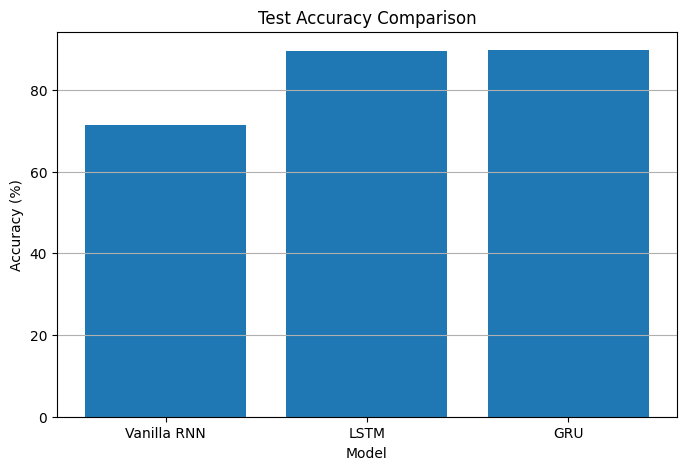

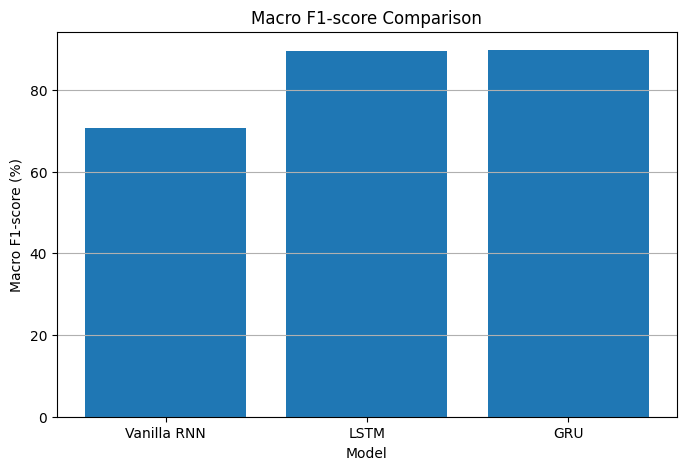

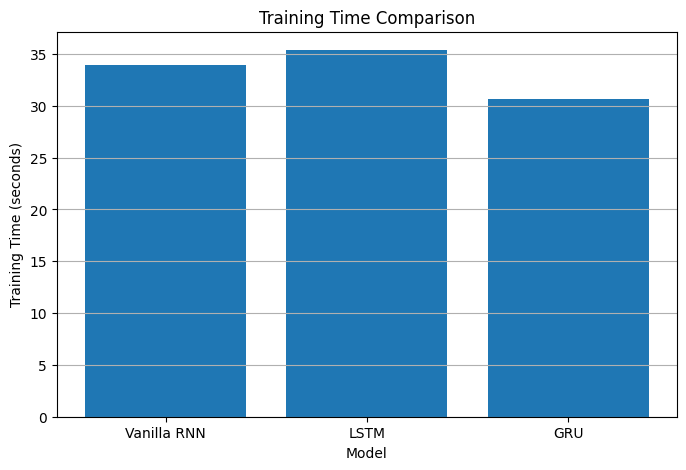

In [ ]:

# ============================================================
# STEP 12-16: MODEL COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create comparison table
# ------------------------------------------------------------

comparison_table = pd.DataFrame([

    rnn_results,

    lstm_results,

    gru_results

])

print("================================================")
print("RNN vs LSTM vs GRU COMPARISON")
print("================================================")

print(comparison_table)

# ------------------------------------------------------------
# 2. Save comparison table
# ------------------------------------------------------------

comparison_table.to_csv(

    "rnn_lstm_gru_comparison.csv",

    index=False

)

print("\nComparison table saved.")

# ------------------------------------------------------------
# 3. Plot test accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(

    comparison_table["Model"],

    comparison_table["Accuracy"]

)

plt.title("Test Accuracy Comparison")

plt.xlabel("Model")

plt.ylabel("Accuracy (%)")

plt.grid(
    axis="y"
)

plt.show()

# ------------------------------------------------------------
# 4. Plot Macro F1-score
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(

    comparison_table["Model"],

    comparison_table["Macro F1"]

)

plt.title("Macro F1-score Comparison")

plt.xlabel("Model")

plt.ylabel("Macro F1-score (%)")

plt.grid(
    axis="y"
)

plt.show()

# ------------------------------------------------------------
# 5. Plot training time
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(

    comparison_table["Model"],

    comparison_table["Training Time"]

)

plt.title("Training Time Comparison")

plt.xlabel("Model")

plt.ylabel("Training Time (seconds)")

plt.grid(
    axis="y"
)

plt.show()

In [ ]:

import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dropout, Dense
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score


# Sequence lengths to test
sequence_lengths = [32, 64, 128]

# Store results
sequence_results = []

# Store histories
sequence_histories = {}


for sequence_length in sequence_lengths:

    print("\n====================================")
    print("Training model with sequence length:", sequence_length)
    print("====================================")

    # Select only the required number of time steps
    X_train_current = X_train[:, :sequence_length, :]
    X_val_current = X_val[:, :sequence_length, :]
    X_test_current = X_test[:, :sequence_length, :]

    print("Training data shape:", X_train_current.shape)
    print("Validation data shape:", X_val_current.shape)
    print("Testing data shape:", X_test_current.shape)

    # Clear previous TensorFlow model
    tf.keras.backend.clear_session()

    # Start timer
    start_time = time.time()

    # Create the same RNN classifier
    model = Sequential([
        Input(shape=(sequence_length, 9)),

        SimpleRNN(32),

        Dropout(0.2),

        Dense(16, activation="relu"),

        Dense(6, activation="softmax")
    ])

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train model
    history = model.fit(
        X_train_current,
        y_train,
        validation_data=(X_val_current, y_val),
        epochs=30,
        batch_size=32,
        verbose=1
    )

    # Calculate training time
    training_time = time.time() - start_time

    # Evaluate model
    test_loss, test_accuracy = model.evaluate(
        X_test_current,
        y_test,
        verbose=0
    )

    # Predict labels
    y_probability = model.predict(
        X_test_current,
        verbose=0
    )

    y_pred = np.argmax(y_probability, axis=1)

    # Calculate metrics
    macro_precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    # Store history
    sequence_histories[sequence_length] = history

    # Store results
    sequence_results.append({
        "Sequence Length": sequence_length,
        "Test Accuracy": test_accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Parameters": model.count_params(),
        "Training Time (seconds)": training_time
    })

    print("\nResults for sequence length", sequence_length)
    print("Test Accuracy:", test_accuracy)
    print("Macro Precision:", macro_precision)
    print("Macro Recall:", macro_recall)
    print("Macro F1:", macro_f1)
    print("Parameters:", model.count_params())
    print("Training Time:", training_time)


# Convert results into a table
sequence_table = pd.DataFrame(sequence_results)

print("\nFinal Sequence Length Comparison:")
display(sequence_table)

# Save results
sequence_table.to_csv(
    "Sequence_Length_Comparison.csv",
    index=False
)


Training model with sequence length: 32
Training data shape: (2550, 32, 9)
Validation data shape: (450, 32, 9)
Testing data shape: (2947, 32, 9)
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.4275 - loss: 1.5381 - val_accuracy: 0.6067 - val_loss: 1.1951
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6314 - loss: 1.0045 - val_accuracy: 0.6444 - val_loss: 0.8694
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6557 - loss: 0.8170 - val_accuracy: 0.6756 - val_loss: 0.7480
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6714 - loss: 0.7280 - val_accuracy: 0.6867 - val_loss: 0.7041
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6776 - loss: 0.6682 - val_accuracy: 0.6933 - val_loss: 0.6782
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7012 - loss: 0.6438 - val_accuracy: 0.6822 - val_loss: 0.6635
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7047 - loss: 0.6229 - val_accurac

,Sequence Length,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Parameters,Training Time (seconds)
0,32,0.743129,0.738348,0.730613,0.731302,1974,25.300848
1,64,0.757041,0.764547,0.752752,0.744828,1974,25.372698
2,128,0.794706,0.802825,0.787378,0.789410,1974,36.668174


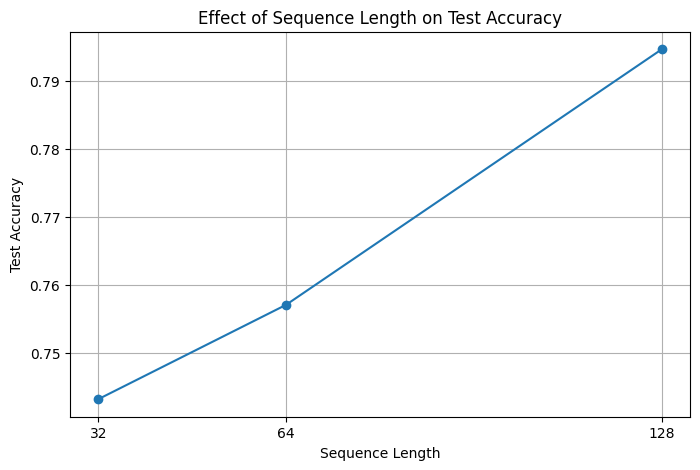

In [ ]:

plt.figure(figsize=(8, 5))

plt.plot(
    sequence_table["Sequence Length"],
    sequence_table["Test Accuracy"],
    marker="o"
)

plt.title("Effect of Sequence Length on Test Accuracy")
plt.xlabel("Sequence Length")
plt.ylabel("Test Accuracy")
plt.xticks([32, 64, 128])
plt.grid()
plt.show()

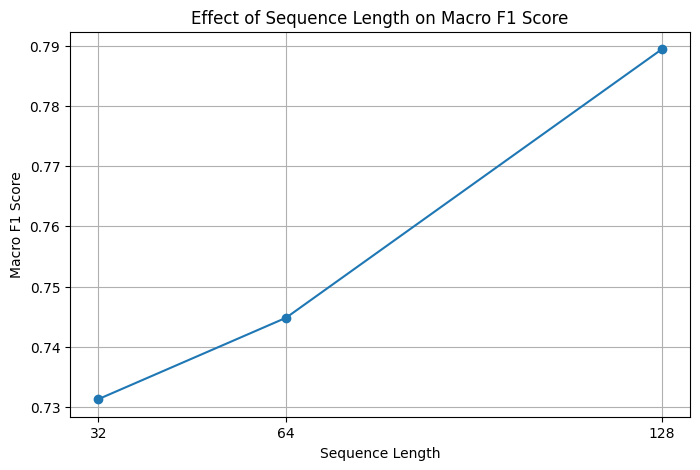

In [ ]:

plt.figure(figsize=(8, 5))

plt.plot(
    sequence_table["Sequence Length"],
    sequence_table["Macro F1"],
    marker="o"
)

plt.title("Effect of Sequence Length on Macro F1 Score")
plt.xlabel("Sequence Length")
plt.ylabel("Macro F1 Score")
plt.xticks([32, 64, 128])
plt.grid()
plt.show()

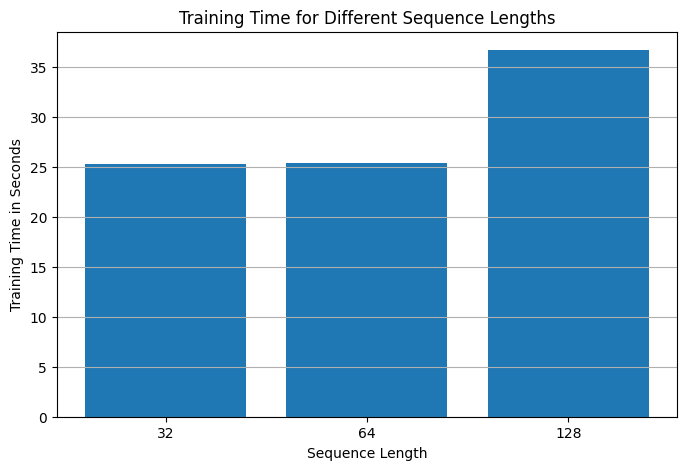

In [ ]:

plt.figure(figsize=(8, 5))

plt.bar(
    sequence_table["Sequence Length"].astype(str),
    sequence_table["Training Time (seconds)"]
)

plt.title("Training Time for Different Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Training Time in Seconds")
plt.grid(axis="y")
plt.show()

In [ ]:
!pip install -q remotezip opencv-python

In [ ]:
!pip install -q huggingface_hub opencv-python

In [ ]:
import os

dataset_path = "/content/UCF101_small"

classes = [
    "Basketball",
    "Biking",
    "Walking",
    "Running",
    "TennisSwing"
]

for class_name in classes:
    os.makedirs(
        os.path.join(dataset_path, class_name),
        exist_ok=True
    )

print("Folders created successfully!")

Folders created successfully!


In [ ]:
!pip install opencv-python tensorflow scikit-learn matplotlib -q

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
DATASET_PATH = "/content/UCF101_small"

classes = [
    "Basketball",
    "Biking",
    "Walking",
    "Running",
    "TennisSwing"
]

NUM_FRAMES = 10
MAX_VIDEOS_PER_CLASS = 15

In [ ]:
for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.exists(class_path):

        videos = [
            file for file in os.listdir(class_path)
            if file.endswith(".avi")
        ]

        print(class_name, ":", len(videos), "videos")

    else:
        print(class_name, ": FOLDER NOT FOUND")

Basketball : 0 videos
Biking : 0 videos
Walking : 0 videos
Running : 0 videos
TennisSwing : 0 videos


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    print("\nFOLDER:", root)

    for file in files[:10]:
        print("   ", file)

    if len(files) > 10:
        print("    ...")


FOLDER: /content
    UCI HAR Dataset.names
    UCI_HAR.zip
    UCF101.rar
    Sequence_Length_Comparison.csv
    UCI HAR Dataset.zip
    rnn_lstm_gru_comparison.csv

FOLDER: /content/.config
    .last_opt_in_prompt.yaml
    gce
    config_sentinel
    .last_update_check.json
    .last_survey_prompt.yaml
    active_config
    hidden_gcloud_config_universe_descriptor_data_cache_configs.db
    default_configs.db

FOLDER: /content/.config/configurations
    config_default

FOLDER: /content/.config/logs

FOLDER: /content/.config/logs/2026.09.04
    13.32.19.320548.log
    13.32.37.014185.log
    13.32.37.832911.log
    13.31.54.252184.log
    13.32.27.247672.log
    13.32.28.853654.log

FOLDER: /content/UCF101_selected

FOLDER: /content/UCF101_subset

FOLDER: /content/UCF101_small

FOLDER: /content/UCF101_small/val

FOLDER: /content/UCF101_small/val/Biking

FOLDER: /content/UCF101_small/val/WalkingWithDog

FOLDER: /content/UCF101_small/val/Basketball

FOLDER: /content/UCF101_small/TennisSw

In [ ]:
import os

base_path = "/content/UCF101_small"

for root, dirs, files in os.walk(base_path):

    avi_files = [
        f for f in files
        if f.lower().endswith(".avi")
    ]

    if len(avi_files) > 0:
        print("\n", root)
        print("Number of videos:", len(avi_files))
        print("First few:", avi_files[:3])

In [ ]:
import requests
import os

url = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"

output_file = "/content/UCF101.rar"

print("Downloading UCF101...")

response = requests.get(url, stream=True)

print("Status code:", response.status_code)

if response.status_code == 200:

    with open(output_file, "wb") as file:

        for chunk in response.iter_content(chunk_size=1024 * 1024):

            if chunk:
                file.write(chunk)

    size_mb = os.path.getsize(output_file) / (1024 * 1024)

    print("Download completed.")
    print("File size:", round(size_mb, 2), "MB")

else:

    print("Download failed.")

SSLError: HTTPSConnectionPool(host='www.crcv.ucf.edu', port=443): Max retries exceeded with url: /data/UCF101/UCF101.rar (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)')))

In [ ]:
import os

file_path = "/content/UCF101.rar"

if os.path.exists(file_path):

    size = os.path.getsize(file_path) / (1024 * 1024)

    print("File exists:", True)
    print("File size:", round(size, 2), "MB")

else:

    print("File does not exist")

File exists: True
File size: 0.0 MB


In [ ]:
!rm -f /content/UCF101.rar

In [ ]:
!wget --no-check-certificate -O /content/UCF101.rar \
https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

--2026-09-18 09:36:10--  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 6932971618 (6.5G) [application/x-rar-compressed]
Saving to: ‘/content/UCF101.rar’

/content/UCF101.rar  15%[==>                 ]   1.01G  12.8MB/s    in 74s     

2026-09-18 09:37:25 (14.0 MB/s) - Connection closed at byte 1086258723. Retrying.

--2026-09-18 09:37:26--  (try: 2)  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 206 Partial Content
Length: 6932971618 (6.5G), 5846712895 (5.4G) remaining [application/x-rar-compressed]
Saving to: ‘/content/UCF101.rar’

/content/UCF101.rar 100%[

In [ ]:
import os

file_path = "/content/UCF101.rar"

if os.path.exists(file_path):
    size_mb = os.path.getsize(file_path) / (1024 * 1024)

    print("File exists:", True)
    print("File size:", round(size_mb, 2), "MB")
else:
    print("File does not exist")

File exists: True
File size: 6611.8 MB


In [ ]:
!unrar t /content/UCF101.rar

Streaming output truncated to the last 5000 lines.
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g16_c02.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g16_c03.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g16_c04.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g16_c05.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g16_c06.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g16_c07.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g17_c01.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g17_c02.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g17_c03.avi             62%  OK 
Testing     UCF-101/PlayingGuitar/v_PlayingGuitar_g17_c04.avi             62%  OK 
Testing     UCF-101/PlayingGu

In [ ]:
import os

base_path = "/content/UCF101_small"

classes = ["Basketball", "Biking", "WalkingWithDog"]

for class_name in classes:
    os.makedirs(os.path.join(base_path, class_name), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [ ]:
!unrar x -inul /content/UCF101.rar "UCF-101/Basketball/*" /content/UCF101_small/
!unrar x -inul /content/UCF101.rar "UCF-101/Biking/*" /content/UCF101_small/
!unrar x -inul /content/UCF101.rar "UCF-101/WalkingWithDog/*" /content/UCF101_small/

print("Selected classes extracted!")

Selected classes extracted!


In [ ]:
import os

for class_name in classes:
    folder = os.path.join(base_path, class_name)
    videos = [f for f in os.listdir(folder) if f.endswith(".avi")]

    print(class_name, ":", len(videos), "videos")

Basketball : 0 videos
Biking : 0 videos
WalkingWithDog : 0 videos


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    avi_files = [f for f in files if f.lower().endswith(".avi")]

    if avi_files:
        print("\nFolder:", root)
        print("Number of videos:", len(avi_files))
        print("First few:", avi_files[:5])


Folder: /content/UCF101_small/UCF-101/Biking
Number of videos: 134
First few: ['v_Biking_g05_c05.avi', 'v_Biking_g22_c03.avi', 'v_Biking_g01_c01.avi', 'v_Biking_g12_c04.avi', 'v_Biking_g20_c02.avi']

Folder: /content/UCF101_small/UCF-101/WalkingWithDog
Number of videos: 123
First few: ['v_WalkingWithDog_g03_c01.avi', 'v_WalkingWithDog_g13_c01.avi', 'v_WalkingWithDog_g11_c02.avi', 'v_WalkingWithDog_g19_c02.avi', 'v_WalkingWithDog_g20_c04.avi']

Folder: /content/UCF101_small/UCF-101/Basketball
Number of videos: 134
First few: ['v_Basketball_g19_c02.avi', 'v_Basketball_g12_c04.avi', 'v_Basketball_g20_c04.avi', 'v_Basketball_g25_c05.avi', 'v_Basketball_g20_c05.avi']


In [ ]:
DATASET_PATH = "/content/UCF101_small/UCF-101"

In [ ]:
import os
import shutil

DATASET_PATH = "/content/UCF101_small/UCF-101"
SMALL_PATH = "/content/UCF101_selected"

classes = ["Basketball", "Biking", "WalkingWithDog"]

for class_name in classes:

    source_folder = os.path.join(DATASET_PATH, class_name)
    target_folder = os.path.join(SMALL_PATH, class_name)

    os.makedirs(target_folder, exist_ok=True)

    videos = [f for f in os.listdir(source_folder) if f.endswith(".avi")]

    # Take only first 10 videos
    videos = videos[:10]

    for video in videos:
        source = os.path.join(source_folder, video)
        target = os.path.join(target_folder, video)
        shutil.copy2(source, target)

    print(class_name, ":", len(videos), "videos copied")

print("\nSmall dataset created successfully!")

Basketball : 10 videos copied
Biking : 10 videos copied
WalkingWithDog : 10 videos copied

Small dataset created successfully!


Dataset path: /content/UCF101_selected
Classes: ['Basketball', 'Biking', 'WalkingWithDog']
Number of frames per video: 10
Frame size: (224, 224)
Basketball : 10 videos
Biking : 10 videos
WalkingWithDog : 10 videos
Video: /content/UCF101_selected/Basketball/v_Basketball_g19_c02.avi
Number of frames extracted: 10
Frame shape: (224, 224, 3)
All frames shape: (10, 224, 224, 3)


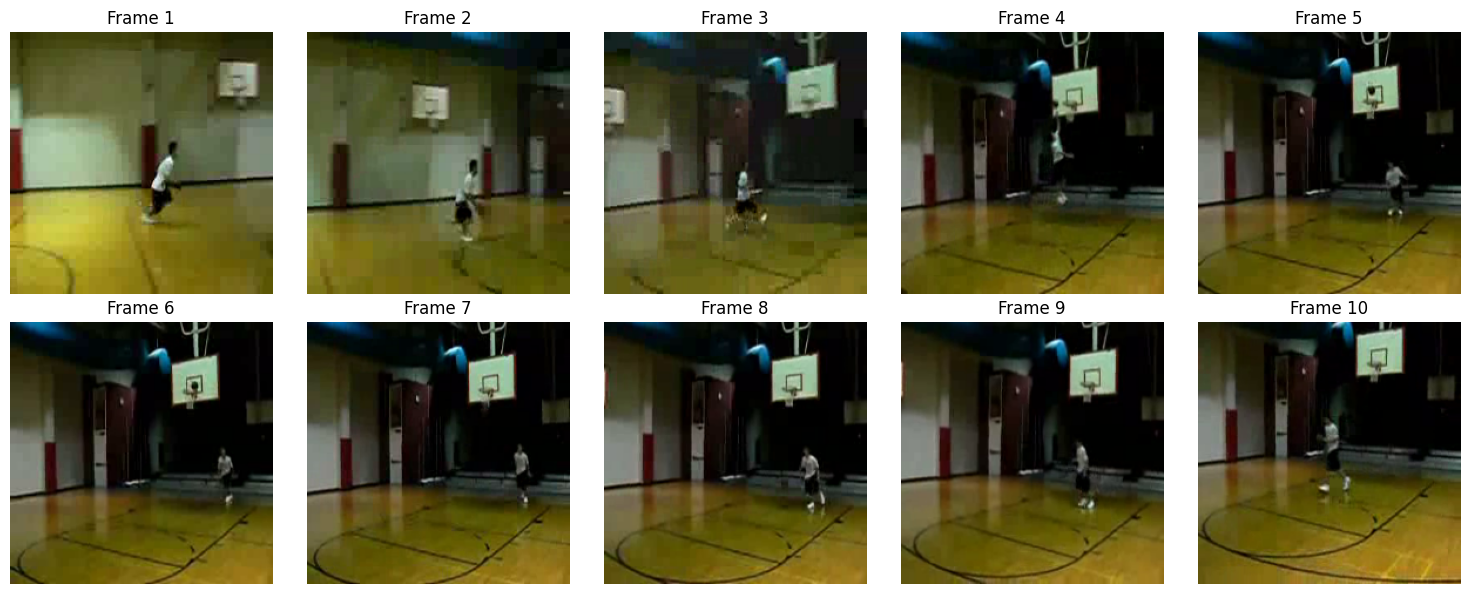

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATASET_PATH = "/content/UCF101_selected"

classes = ["Basketball", "Biking", "WalkingWithDog"]

NUM_FRAMES = 10
IMAGE_SIZE = (224, 224)

print("Dataset path:", DATASET_PATH)
print("Classes:", classes)
print("Number of frames per video:", NUM_FRAMES)
print("Frame size:", IMAGE_SIZE)
for class_name in classes:

    folder = os.path.join(DATASET_PATH, class_name)

    videos = [f for f in os.listdir(folder) if f.endswith(".avi")]

    print(class_name, ":", len(videos), "videos")
def extract_frames(video_path, num_frames=10):

    video = cv2.VideoCapture(video_path)

    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_numbers = np.linspace(
        0,
        total_frames - 1,
        num_frames
    ).astype(int)

    frames = []

    for frame_number in frame_numbers:

        video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

        success, frame = video.read()

        if success:

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            frame = cv2.resize(frame, IMAGE_SIZE)

            frames.append(frame)

    video.release()

    return np.array(frames)
video_path = os.path.join(
    DATASET_PATH,
    "Basketball",
    os.listdir(os.path.join(DATASET_PATH, "Basketball"))[0]
)

frames = extract_frames(video_path)

print("Video:", video_path)
print("Number of frames extracted:", len(frames))
print("Frame shape:", frames[0].shape)
print("All frames shape:", frames.shape)
plt.figure(figsize=(15, 6))

for i in range(len(frames)):

    plt.subplot(2, 5, i + 1)

    plt.imshow(frames[i])

    plt.title("Frame " + str(i + 1))

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

# Freeze CNN
cnn.trainable = False

print("MobileNetV2 loaded successfully")
print("CNN feature dimension:", cnn.output_shape[-1])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 loaded successfully
CNN feature dimension: 1280


In [ ]:
frames_for_cnn = preprocess_input(
    frames.astype("float32")
)

features = cnn.predict(
    frames_for_cnn,
    verbose=0
)

print("Feature shape:", features.shape)

Feature shape: (10, 1280)


In [ ]:
X = []
y = []

for class_index, class_name in enumerate(classes):

    folder = os.path.join(DATASET_PATH, class_name)

    videos = [
        f for f in os.listdir(folder)
        if f.endswith(".avi")
    ]

    for video_name in videos:

        video_path = os.path.join(folder, video_name)

        frames = extract_frames(video_path)

        # Make sure exactly 10 frames are available
        if len(frames) != NUM_FRAMES:
            continue

        frames_for_cnn = preprocess_input(
            frames.astype("float32")
        )

        features = cnn.predict(
            frames_for_cnn,
            verbose=0
        )

        X.append(features)
        y.append(class_index)

print("Feature extraction completed!")

Feature extraction completed!


In [ ]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (28, 10, 1280)
y shape: (28,)


In [ ]:
print("========================================")
print("CNN FEATURE EXTRACTION OBSERVATION")
print("========================================")

print("Number of videos:", X.shape[0])
print("Frames per video:", X.shape[1])
print("CNN feature dimension (D):", X.shape[2])

print("\nInput frame shape:")
print("(224, 224, 3)")

print("\nFeature sequence for one video:")
print(X[0].shape)

print("\nComplete recurrent input shape:")
print(X.shape)

print("\nFor a batch of B videos:")
print("(B, 10, 1280)")

CNN FEATURE EXTRACTION OBSERVATION
Number of videos: 28
Frames per video: 10
CNN feature dimension (D): 1280

Input frame shape:
(224, 224, 3)

Feature sequence for one video:
(10, 1280)

Complete recurrent input shape:
(28, 10, 1280)

For a batch of B videos:
(B, 10, 1280)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (22, 10, 1280)
Testing data: (6, 10, 1280)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        32,
        input_shape=(10, 1280)
    )
)

model.add(Dense(32, activation="relu"))

model.add(
    Dense(
        len(classes),
        activation="softmax"
    )
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,219 (661.01 KB)

 Trainable params: 169,219 (661.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.5294 - loss: 1.1199 - val_accuracy: 0.0000e+00 - val_loss: 1.4297
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7059 - loss: 0.8365 - val_accuracy: 0.2000 - val_loss: 1.1047
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7059 - loss: 0.6738 - val_accuracy: 0.4000 - val_loss: 1.0014
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.4694 - val_accuracy: 0.8000 - val_loss: 0.6857
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.3100 - val_accuracy: 0.8000 - val_loss: 0.7289
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.2225 - val_accuracy: 0.8000 - val_loss: 0.7091
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.1536 - val_accuracy: 0.8000 - val_loss: 0.6801
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.1595 - val_accuracy: 1.0000 - val_loss: 0.

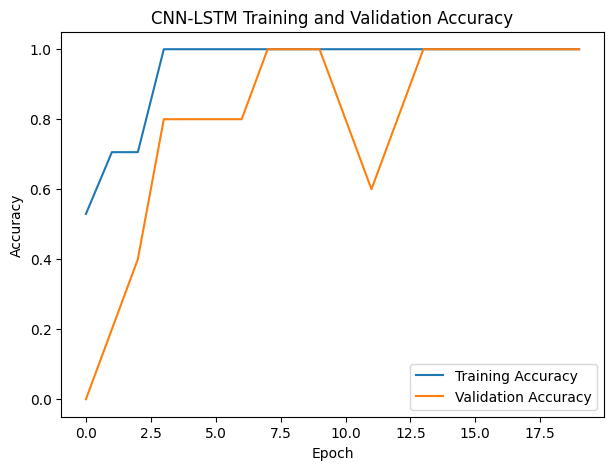

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-LSTM Training and Validation Accuracy")

plt.legend()
plt.show()

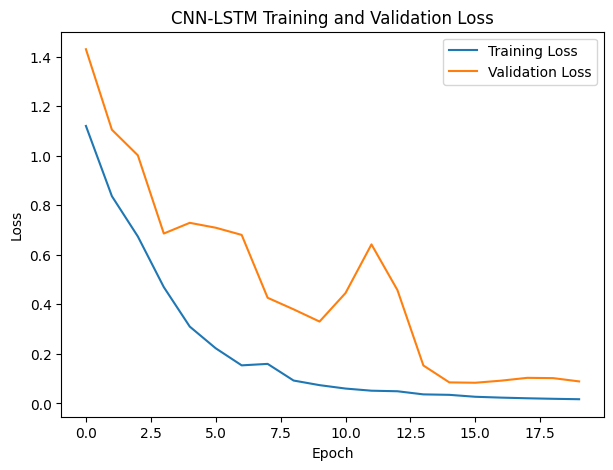

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-LSTM Training and Validation Loss")

plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.2931
Test Accuracy: 0.8333


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Confusion Matrix:
[[2 0 0]
 [0 1 1]
 [0 0 2]]


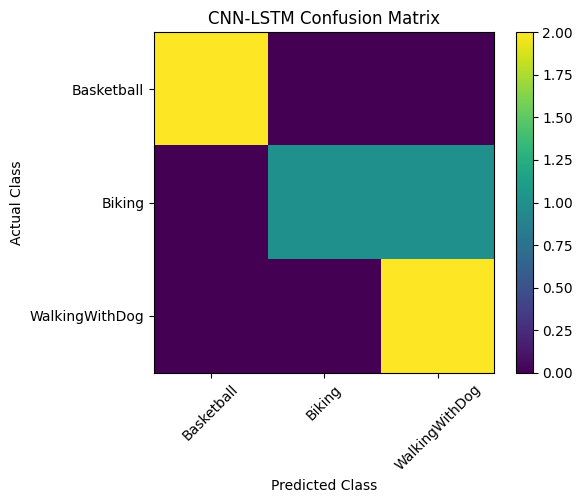

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("CNN-LSTM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes,
        zero_division=0
    )
)

                precision    recall  f1-score   support

    Basketball       1.00      1.00      1.00         2
        Biking       1.00      0.50      0.67         2
WalkingWithDog       0.67      1.00      0.80         2

      accuracy                           0.83         6
     macro avg       0.89      0.83      0.82         6
  weighted avg       0.89      0.83      0.82         6



In [ ]:
sample_index = 0

probabilities = predictions[sample_index]

predicted_index = np.argmax(probabilities)

actual_index = y_test[sample_index]

confidence = probabilities[predicted_index]

print("Predicted class :", classes[predicted_index])
print("Actual class    :", classes[actual_index])
print("Confidence      :", round(float(confidence), 2))

Predicted class : WalkingWithDog
Actual class    : WalkingWithDog
Confidence      : 0.94


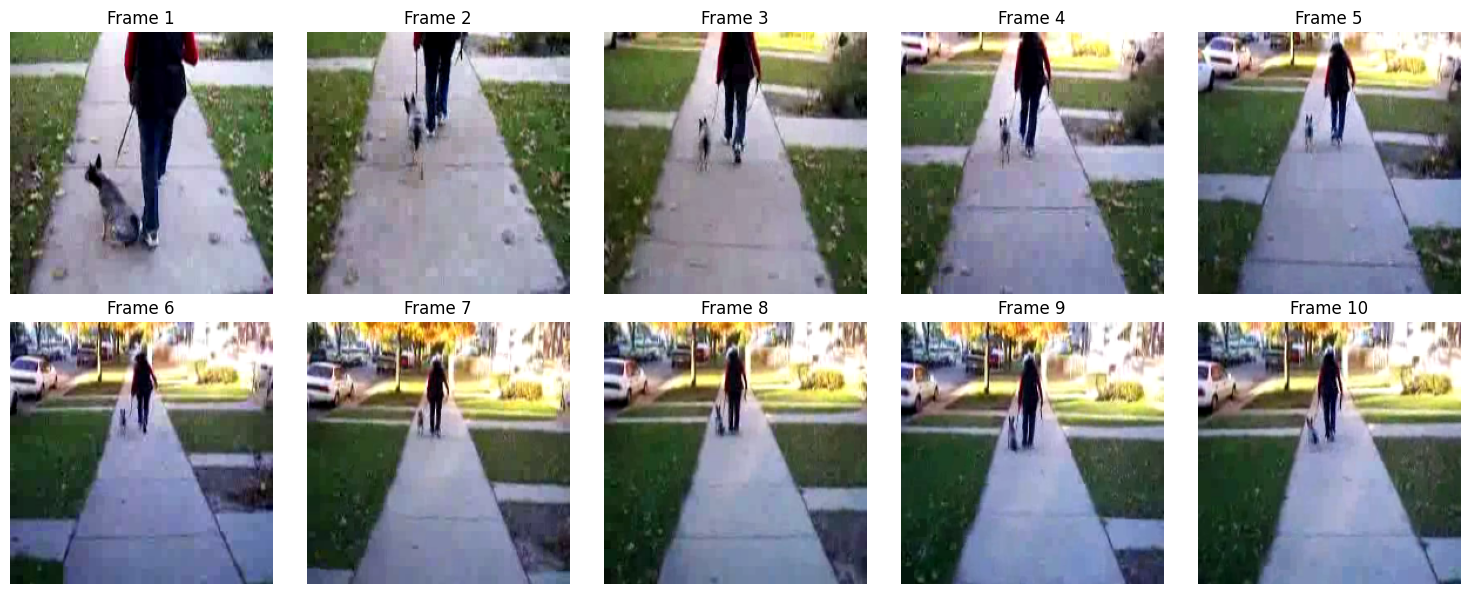

In [ ]:
plt.figure(figsize=(15, 6))

for i in range(len(frames)):

    plt.subplot(2, 5, i + 1)

    plt.imshow(frames[i])

    plt.title("Frame " + str(i + 1))

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

NUM_SAMPLES = 5000
SEQUENCE_LENGTH = 4
VOCAB_SIZE = 10

X_seq = np.random.randint(
    1,
    VOCAB_SIZE,
    size=(NUM_SAMPLES, SEQUENCE_LENGTH)
)

y_seq = np.flip(
    X_seq,
    axis=1
)

print("Input shape :", X_seq.shape)
print("Output shape:", y_seq.shape)

print("\nExample:")
print("Input :", X_seq[0])
print("Output:", y_seq[0])

Input shape : (5000, 4)
Output shape: (5000, 4)

Example:
Input : [8 1 2 5]
Output: [5 2 1 8]


In [ ]:
START_TOKEN = 0

decoder_input = np.zeros_like(y_seq)

decoder_input[:, 0] = START_TOKEN

decoder_input[:, 1:] = y_seq[:, :-1]

print("Decoder input example:")
print(decoder_input[0])

print("Expected output:")
print(y_seq[0])

Decoder input example:
[0 5 2 1]
Expected output:
[5 2 1 8]


In [ ]:
from sklearn.model_selection import train_test_split

encoder_train, encoder_test, decoder_train, decoder_test, output_train, output_test = train_test_split(
    X_seq,
    decoder_input,
    y_seq,
    test_size=0.2,
    random_state=42
)

print("Encoder training:", encoder_train.shape)
print("Decoder training:", decoder_train.shape)
print("Output training:", output_train.shape)

Encoder training: (4000, 4)
Decoder training: (4000, 4)
Output training: (4000, 4)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

# Encoder
encoder_inputs = Input(shape=(SEQUENCE_LENGTH,))

encoder_embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=16
)(encoder_inputs)

encoder_lstm = LSTM(
    32,
    return_state=True
)

encoder_output, state_h, state_c = encoder_lstm(
    encoder_embedding
)

# Decoder
decoder_inputs = Input(shape=(SEQUENCE_LENGTH,))

decoder_embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=16
)(decoder_inputs)

decoder_lstm = LSTM(
    32,
    return_sequences=True
)

decoder_output = decoder_lstm(
    decoder_embedding,
    initial_state=[state_h, state_c]
)

decoder_dense = Dense(
    VOCAB_SIZE,
    activation="softmax"
)

decoder_output = decoder_dense(decoder_output)

# Complete model
seq2seq_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_output
)

seq2seq_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 16)     │        160 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 16)     │        160 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 32),      │      6,272 │ embedding[0][0]   │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 4, 32)     │      6,272 │ embedding_1[0][0… │
│                     │                   │            │ lstm_1[0][1],     │
│                     │                   │            │ lstm_1[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4, 10)     │        330 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,194 (51.54 KB)

 Trainable params: 13,194 (51.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
seq_history = seq2seq_model.fit(
    [encoder_train, decoder_train],
    output_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.2605 - loss: 2.1119 - val_accuracy: 0.3425 - val_loss: 1.7332
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4220 - loss: 1.4923 - val_accuracy: 0.5459 - val_loss: 1.1998
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7223 - loss: 0.8665 - val_accuracy: 0.8594 - val_loss: 0.6182
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9253 - loss: 0.4627 - val_accuracy: 0.9613 - val_loss: 0.3544
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9716 - loss: 0.2838 - val_accuracy: 0.9869 - val_loss: 0.2292
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9897 - loss: 0.1902 - val_accuracy: 0.9934 - val_loss: 0.1601
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9957 - loss: 0.1363 - val_accuracy: 0.9956 - val_loss: 0.1209
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9977 - loss: 0.1043 - val_accurac

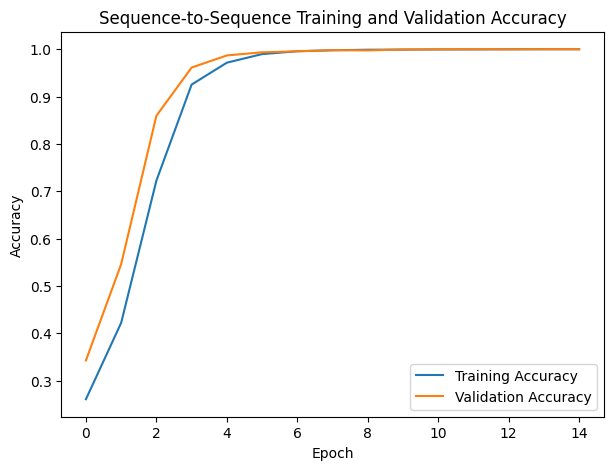

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    seq_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    seq_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Sequence-to-Sequence Training and Validation Accuracy")

plt.legend()
plt.show()

In [ ]:
test_sample = encoder_test[0:1]

decoder_sample = decoder_test[0:1]

prediction = seq2seq_model.predict(
    [test_sample, decoder_sample],
    verbose=0
)

predicted_sequence = np.argmax(
    prediction,
    axis=-1
)

print("Input sequence    :", test_sample[0])
print("Actual sequence   :", output_test[0])
print("Predicted sequence:", predicted_sequence[0])

Input sequence    : [1 4 6 2]
Actual sequence   : [2 6 4 1]
Predicted sequence: [2 6 4 1]


In [ ]:
# Predict all test samples

test_predictions = seq2seq_model.predict(
    [encoder_test, decoder_test],
    verbose=0
)

predicted_sequences = np.argmax(
    test_predictions,
    axis=-1
)

print("5 Test Examples")
print("=" * 60)

for i in range(5):

    print("\nExample", i + 1)

    print("Input Sequence    :", encoder_test[i])
    print("Expected Output   :", output_test[i])
    print("Predicted Output  :", predicted_sequences[i])

5 Test Examples

Example 1
Input Sequence    : [1 4 6 2]
Expected Output   : [2 6 4 1]
Predicted Output  : [2 6 4 1]

Example 2
Input Sequence    : [6 8 4 9]
Expected Output   : [9 4 8 6]
Predicted Output  : [9 4 8 6]

Example 3
Input Sequence    : [2 9 2 9]
Expected Output   : [9 2 9 2]
Predicted Output  : [9 2 9 2]

Example 4
Input Sequence    : [1 7 7 9]
Expected Output   : [9 7 7 1]
Predicted Output  : [9 7 7 1]

Example 5
Input Sequence    : [9 3 6 4]
Expected Output   : [4 6 3 9]
Predicted Output  : [4 6 3 9]


In [ ]:
correct_tokens = np.sum(
    predicted_sequences == output_test
)

total_tokens = output_test.size

token_accuracy = correct_tokens / total_tokens

print("Token Accuracy:", round(token_accuracy * 100, 2), "%")

Token Accuracy: 99.9 %


In [ ]:
correct_sequences = np.all(
    predicted_sequences == output_test,
    axis=1
).sum()

total_sequences = len(output_test)

sequence_accuracy = correct_sequences / total_sequences

print("Sequence Accuracy:", round(sequence_accuracy * 100, 2), "%")

Sequence Accuracy: 99.6 %


In [ ]:
training_loss = seq_history.history["loss"][-1]

validation_loss = seq_history.history["val_loss"][-1]

print("Training Loss   :", round(training_loss, 4))
print("Validation Loss :", round(validation_loss, 4))

Training Loss   : 0.0284
Validation Loss : 0.028


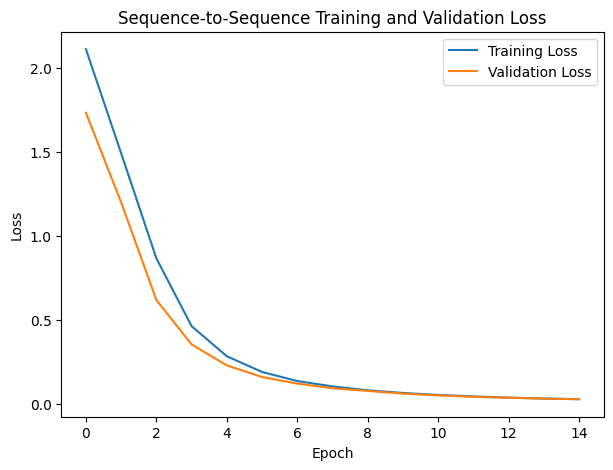

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    seq_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    seq_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Sequence-to-Sequence Training and Validation Loss")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

cnn_lstm_accuracy = accuracy_score(y_test, y_pred)

cnn_lstm_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

cnn_lstm_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

cnn_lstm_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("CNN-LSTM Results")
print("==============================")

print("Accuracy :", round(cnn_lstm_accuracy, 4))
print("Precision:", round(cnn_lstm_precision, 4))
print("Recall   :", round(cnn_lstm_recall, 4))
print("F1 Score :", round(cnn_lstm_f1, 4))

CNN-LSTM Results
Accuracy : 0.8333
Precision: 0.8889
Recall   : 0.8333
F1 Score : 0.8222
